# Data Preprocessing

## 1. Import

In [14]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from glob import glob

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMAGE_SIZE = 256

## 2. Load Dataset

In [15]:
RAW_REAL_DIR = Path("../data/Input/real")
RAW_COMIC_DIR = Path("../data/Input/comic")

real_files = sorted(
    f for f in RAW_REAL_DIR.iterdir() if f.suffix.lower() in IMG_EXTENSIONS
)
comic_files = sorted(
    f for f in RAW_COMIC_DIR.iterdir() if f.suffix.lower() in IMG_EXTENSIONS
)

print(f"Real images found:  {len(real_files)}")
print(f"Comic images found: {len(comic_files)}")

# verify every real image has a matching comic image
missing = [f.name for f in real_files if not (RAW_COMIC_DIR / f.name).exists()]
if missing:
    print(f"WARNING: {len(missing)} real images have no comic pair!")
else:
    print("All real images have matching comic pairs.")

Real images found:  10000
Comic images found: 10000
All real images have matching comic pairs.


## 3. Resize Images

Resize all 512×512 raw images down to `IMAGE_SIZE × IMAGE_SIZE` and save them into a preprocessed directory. This avoids repeating the resize on every training epoch.

In [16]:
PREPROCESSED_DIR = Path("../data/preprocessed")
PREP_REAL_DIR = PREPROCESSED_DIR / "real"
PREP_COMIC_DIR = PREPROCESSED_DIR / "comic"


def resize_and_save(src_files, dst_dir, size):
    """Resize a list of images to (size, size) and save to dst_dir."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    already_done = {f.name for f in dst_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS}
    skipped, saved = 0, 0

    for src_path in src_files:
        if src_path.name in already_done:
            skipped += 1
            continue
        img = Image.open(src_path).convert("RGB")
        img = img.resize((size, size), Image.LANCZOS)
        img.save(dst_dir / src_path.name)
        saved += 1

    print(f"  Saved {saved} new images, skipped {skipped} existing  ->  {dst_dir}")


print(f"Resizing images to {IMAGE_SIZE}x{IMAGE_SIZE} ...\n")

print("Real faces:")
resize_and_save(real_files, PREP_REAL_DIR, IMAGE_SIZE)

print("Comic faces:")
resize_and_save(comic_files, PREP_COMIC_DIR, IMAGE_SIZE)

# quick verification
n_real = len(list(PREP_REAL_DIR.iterdir()))
n_comic = len(list(PREP_COMIC_DIR.iterdir()))
print(f"\nPreprocessed counts — Real: {n_real}, Comic: {n_comic}")

Resizing images to 256x256 ...

Real faces:
  Saved 10000 new images, skipped 0 existing  ->  ../data/preprocessed/real
Comic faces:
  Saved 10000 new images, skipped 0 existing  ->  ../data/preprocessed/comic

Preprocessed counts — Real: 10000, Comic: 10000


## 4. Train / Validation Split

Split the preprocessed pairs into **80% train** and **20% validation**. Both the real and comic images for each pair are moved together so the pairing is preserved.

In [17]:
VAL_RATIO = 0.2

SPLIT_DIR = Path("../data/split")
TRAIN_REAL = SPLIT_DIR / "train" / "real"
TRAIN_COMIC = SPLIT_DIR / "train" / "comic"
VAL_REAL = SPLIT_DIR / "val" / "real"
VAL_COMIC = SPLIT_DIR / "val" / "comic"

# get all preprocessed filenames (sorted for reproducibility)
all_names = sorted(f.name for f in PREP_REAL_DIR.iterdir() if f.suffix.lower() in IMG_EXTENSIONS)
print(f"Total preprocessed pairs: {len(all_names)}")

# shuffle with fixed seed, then split
random.shuffle(all_names)
split_idx = int(len(all_names) * (1 - VAL_RATIO))
train_names = all_names[:split_idx]
val_names = all_names[split_idx:]

print(f"Train: {len(train_names)} pairs")
print(f"Val:   {len(val_names)} pairs")

Total preprocessed pairs: 10000
Train: 8000 pairs
Val:   2000 pairs


In [18]:
def copy_pairs(names, src_real, src_comic, dst_real, dst_comic):
    """Copy real+comic image pairs from preprocessed dirs into split dirs."""
    dst_real.mkdir(parents=True, exist_ok=True)
    dst_comic.mkdir(parents=True, exist_ok=True)
    copied = 0

    for name in names:
        real_src = src_real / name
        comic_src = src_comic / name

        if not real_src.exists() or not comic_src.exists():
            print(f"  SKIPPING {name} — missing source file")
            continue

        shutil.copy2(real_src, dst_real / name)
        shutil.copy2(comic_src, dst_comic / name)
        copied += 1

    return copied


# clear old splits if they exist so we get a clean slate
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
    print("Cleared old split directory.\n")

print("Copying train pairs...")
n_train = copy_pairs(train_names, PREP_REAL_DIR, PREP_COMIC_DIR, TRAIN_REAL, TRAIN_COMIC)
print(f"  Copied {n_train} train pairs.\n")

print("Copying val pairs...")
n_val = copy_pairs(val_names, PREP_REAL_DIR, PREP_COMIC_DIR, VAL_REAL, VAL_COMIC)
print(f"  Copied {n_val} val pairs.")

Copying train pairs...
  Copied 8000 train pairs.

Copying val pairs...
  Copied 2000 val pairs.


## 5. Normalize & Save as NumPy Arrays

Convert each split's images to float32 tensors normalized to **[-1, 1]** (required by the GAN's `tanh` output layer) and save as `.npy` files. This means the training notebook can load data directly without any transforms.

**Normalization:** `pixel / 255.0` maps `[0, 255] -> [0, 1]`, then `* 2 - 1` maps `[0, 1] -> [-1, 1]`.

In [19]:
def load_and_normalize(image_dir):
    """Load all images from a directory, normalize to [-1, 1], return as (N, C, H, W) float32 array."""
    paths = sorted(f for f in image_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS)
    images = []

    for p in paths:
        img = np.array(Image.open(p).convert("RGB"))       # (H, W, 3), uint8 [0, 255]
        img = img.astype(np.float32) / 255.0                # [0, 1]
        img = img * 2.0 - 1.0                               # [-1, 1]
        img = img.transpose(2, 0, 1)                        # (3, H, W) — channels first for PyTorch
        images.append(img)

    return np.stack(images)                                  # (N, 3, H, W)


NPY_DIR = Path("../data/npy")
NPY_DIR.mkdir(parents=True, exist_ok=True)

print("Normalizing train real...")
train_real_npy = load_and_normalize(TRAIN_REAL)
np.save(NPY_DIR / "train_real.npy", train_real_npy)
print(f"  Shape: {train_real_npy.shape}  |  Range: [{train_real_npy.min():.1f}, {train_real_npy.max():.1f}]")

print("Normalizing train comic...")
train_comic_npy = load_and_normalize(TRAIN_COMIC)
np.save(NPY_DIR / "train_comic.npy", train_comic_npy)
print(f"  Shape: {train_comic_npy.shape}  |  Range: [{train_comic_npy.min():.1f}, {train_comic_npy.max():.1f}]")

print("Normalizing val real...")
val_real_npy = load_and_normalize(VAL_REAL)
np.save(NPY_DIR / "val_real.npy", val_real_npy)
print(f"  Shape: {val_real_npy.shape}  |  Range: [{val_real_npy.min():.1f}, {val_real_npy.max():.1f}]")

print("Normalizing val comic...")
val_comic_npy = load_and_normalize(VAL_COMIC)
np.save(NPY_DIR / "val_comic.npy", val_comic_npy)
print(f"  Shape: {val_comic_npy.shape}  |  Range: [{val_comic_npy.min():.1f}, {val_comic_npy.max():.1f}]")

print(f"\nSaved all .npy files to {NPY_DIR.resolve()}")

Normalizing train real...
  Shape: (8000, 3, 256, 256)  |  Range: [-1.0, 1.0]
Normalizing train comic...
  Shape: (8000, 3, 256, 256)  |  Range: [-1.0, 1.0]
Normalizing val real...
  Shape: (2000, 3, 256, 256)  |  Range: [-1.0, 1.0]
Normalizing val comic...
  Shape: (2000, 3, 256, 256)  |  Range: [-1.0, 1.0]

Saved all .npy files to /Users/utki007/Desktop/Northwestern University/Studies/Quarter 3/Gen AI/comic-face-generator/data/npy


## 6. Verify Split Integrity

Three checks:
1. Every real image in each split has a matching comic image (pair integrity)
2. Train and val sets don't overlap (no data leakage)
3. Image dimensions are correct

In [20]:
def verify_pairs(real_dir, comic_dir, label):
    """Check that every real image has a matching comic image and vice versa."""
    real_names = {f.name for f in real_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS}
    comic_names = {f.name for f in comic_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS}

    real_only = real_names - comic_names
    comic_only = comic_names - real_names

    if real_only:
        print(f"  [{label}] {len(real_only)} real images have NO comic match")
    if comic_only:
        print(f"  [{label}] {len(comic_only)} comic images have NO real match")
    if not real_only and not comic_only:
        print(f"  [{label}] All {len(real_names)} pairs are intact.")

    return real_names, comic_names


# check pair integrity
print("Check 1 — Pair integrity:")
train_real_names, _ = verify_pairs(TRAIN_REAL, TRAIN_COMIC, "train")
val_real_names, _ = verify_pairs(VAL_REAL, VAL_COMIC, "val")

# check for overlap between train and val
print("\nCheck 2 — No overlap between splits:")
overlap = train_real_names & val_real_names
if overlap:
    print(f"  LEAK DETECTED: {len(overlap)} images appear in both splits!")
else:
    print(f"  No overlap. Train ({len(train_real_names)}) and Val ({len(val_real_names)}) are disjoint.")

# check for image dimensions
print("\nCheck 3 — Image dimensions (sampling 20 random images):")
sample_paths = (
    random.sample(sorted(TRAIN_REAL.iterdir()), 10) +
    random.sample(sorted(VAL_REAL.iterdir()), 10)
)
bad_sizes = []
for p in sample_paths:
    img = Image.open(p)
    if img.size != (IMAGE_SIZE, IMAGE_SIZE):
        bad_sizes.append((p.name, img.size))

if bad_sizes:
    print(f"  {len(bad_sizes)} images have wrong dimensions:")
    for name, sz in bad_sizes:
        print(f"    {name}: {sz}")
else:
    print(f"  All sampled images are {IMAGE_SIZE}x{IMAGE_SIZE}.")

Check 1 — Pair integrity:
  [train] All 8000 pairs are intact.
  [val] All 2000 pairs are intact.

Check 2 — No overlap between splits:
  No overlap. Train (8000) and Val (2000) are disjoint.

Check 3 — Image dimensions (sampling 20 random images):
  All sampled images are 256x256.


## 7. Visual Sanity Check

Show a few random pairs from train and val splits to make sure resizing preserved quality and pairs are correctly aligned.

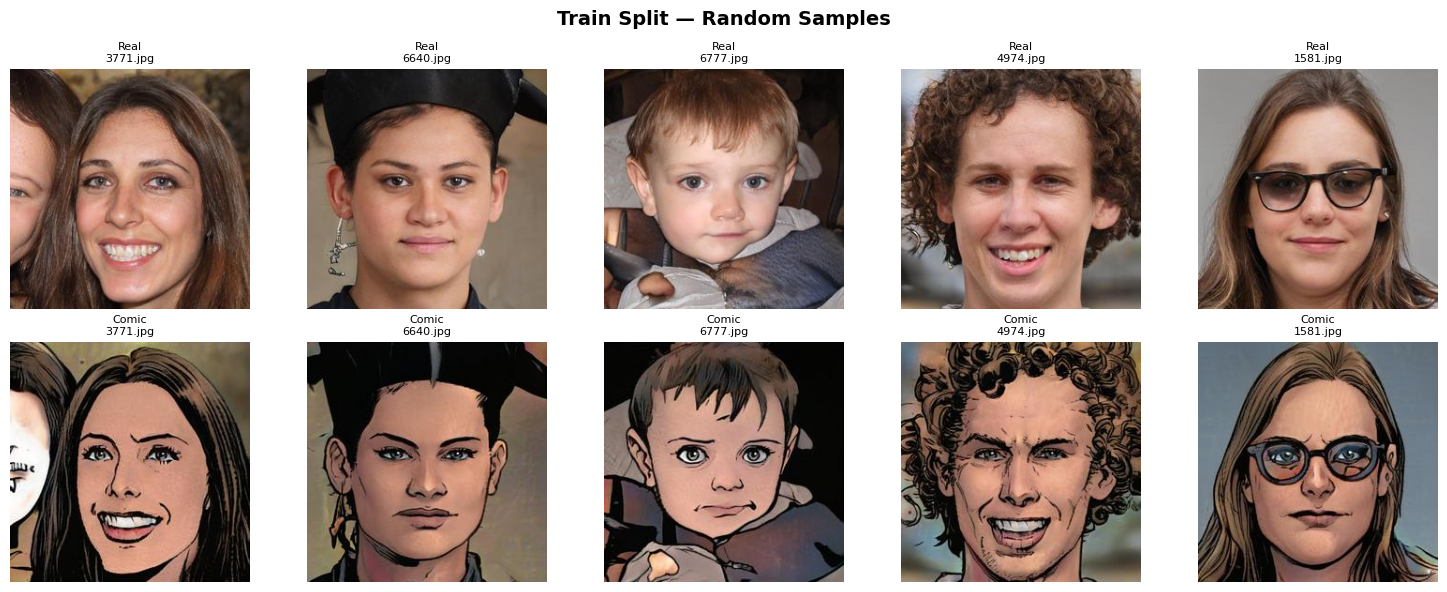

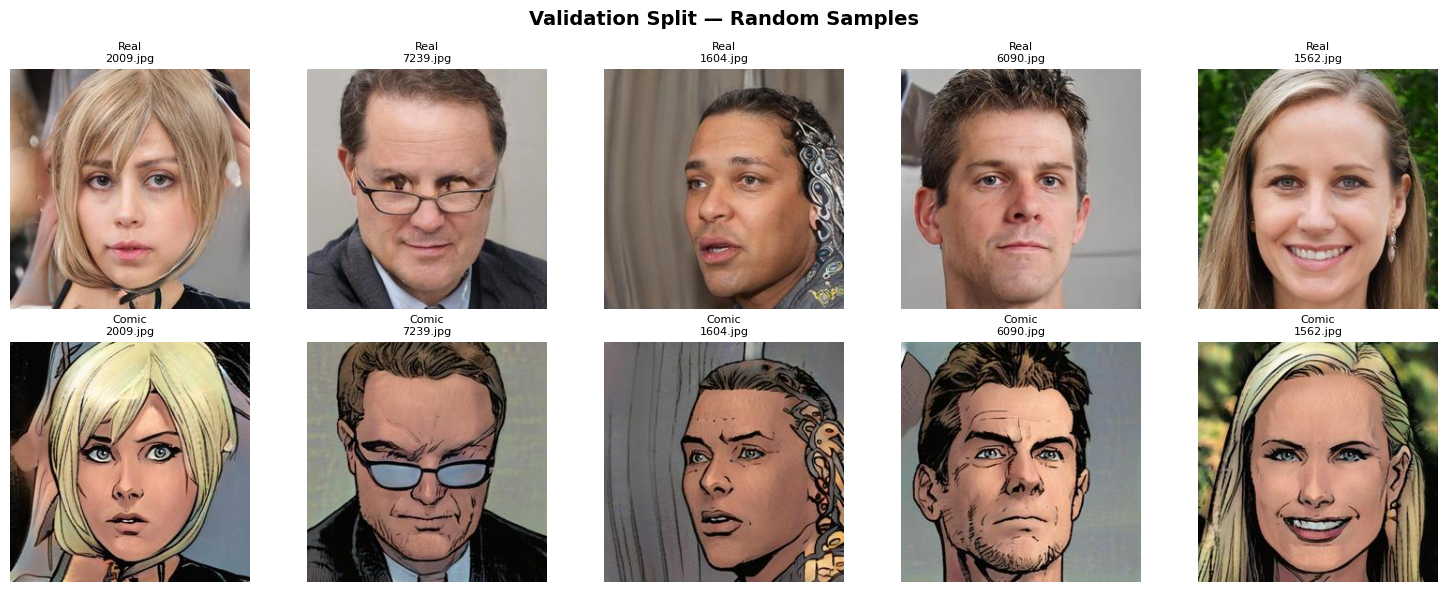

In [21]:
def show_pairs(real_dir, comic_dir, title, n=5):
    """Display n random (real, comic) pairs side by side."""
    names = sorted(f.name for f in real_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS)
    chosen = random.sample(names, min(n, len(names)))

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for i, name in enumerate(chosen):
        real_img = Image.open(real_dir / name)
        comic_img = Image.open(comic_dir / name)

        axes[0, i].imshow(real_img)
        axes[0, i].set_title(f"Real\n{name}", fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(comic_img)
        axes[1, i].set_title(f"Comic\n{name}", fontsize=8)
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


show_pairs(TRAIN_REAL, TRAIN_COMIC, "Train Split — Random Samples")
show_pairs(VAL_REAL, VAL_COMIC, "Validation Split — Random Samples")

## 8. Summary

Final dataset statistics and directory layout for training.

In [22]:
def count_images(directory):
    return len([f for f in directory.iterdir() if f.suffix.lower() in IMG_EXTENSIONS])


print("=" * 55)
print("          PREPROCESSING SUMMARY")
print("=" * 55)
print(f"  Image size:         {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"  Normalization:      [-1, 1]  (channels-first)")
print(f"  Seed:               {SEED}")
print(f"  Val ratio:          {VAL_RATIO}")
print()
print(f"  Raw images:         {len(real_files)} pairs")
print(f"  Preprocessed:       {count_images(PREP_REAL_DIR)} pairs")
print(f"  Train split:        {count_images(TRAIN_REAL)} pairs")
print(f"  Val split:          {count_images(VAL_REAL)} pairs")
print()
print("  .npy files (ready for training):")
for name in ["train_real", "train_comic", "val_real", "val_comic"]:
    arr = np.load(NPY_DIR / f"{name}.npy")
    size_mb = arr.nbytes / (1024 * 1024)
    print(f"    {name}.npy  ->  {arr.shape}  ({size_mb:.1f} MB)")
print()
print("  In train.ipynb, load with:")
print('    train_real = torch.from_numpy(np.load("../data/npy/train_real.npy"))')
print("=" * 55)

          PREPROCESSING SUMMARY
  Image size:         256 x 256
  Normalization:      [-1, 1]  (channels-first)
  Seed:               42
  Val ratio:          0.2

  Raw images:         10000 pairs
  Preprocessed:       10000 pairs
  Train split:        8000 pairs
  Val split:          2000 pairs

  .npy files (ready for training):
    train_real.npy  ->  (8000, 3, 256, 256)  (6000.0 MB)
    train_comic.npy  ->  (8000, 3, 256, 256)  (6000.0 MB)
    val_real.npy  ->  (2000, 3, 256, 256)  (1500.0 MB)
    val_comic.npy  ->  (2000, 3, 256, 256)  (1500.0 MB)

  In train.ipynb, load with:
    train_real = torch.from_numpy(np.load("../data/npy/train_real.npy"))


## 9. Key Findings & Takeaways

1. **Clean, well-paired dataset** — All 10,000 real-comic pairs matched perfectly by filename with zero mismatches, so no manual cleanup or alignment was needed.

2. **Uniform dimensions** — Every raw image was already 512×512×3 (RGB). Resizing to 256×256 was straightforward with no aspect-ratio issues or padding required.

3. **80/20 split** — The dataset was split into **8,000 training** and **2,000 validation** pairs using a fixed seed (`SEED=42`) for reproducibility. Verification confirmed no overlap between splits and all pairs intact.

4. **Normalization to [-1, 1]** — Pixel values were rescaled from `[0, 255]` to `[-1, 1]` to match the `tanh` activation of the generator's output layer. Data is stored in channels-first `(N, 3, H, W)` format, ready for PyTorch.

5. **Saved as `.npy` for fast loading** — The final preprocessed data is saved as four NumPy arrays (`train_real`, `train_comic`, `val_real`, `val_comic`). This avoids re-reading thousands of image files during training and allows the training notebook to load everything with a single `np.load()` call.

6. **No augmentation applied offline** — For pix2pix with paired data, augmentations (random flips, jitter) must be applied identically to both images in a pair. This is better handled on-the-fly in the training loop if needed, not baked into the saved data.